In [1]:
# Cell 1: imports & config
import os, json, joblib, numpy as np, pandas as pd, shap, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import sys
sys.path.append("..")
from src.transforms import select_cols_top7

# ensure plots render in notebook (optional)
# %matplotlib inline

# create output directories (if not already)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../artifacts", exist_ok=True)

# paths - adjust if your structure differs
DATA_PATH = "../data/heart_uci.csv"
MODEL_PATH = "../artifacts/final_lightweight_model_k7_clean.joblib"
FEATURE_MAP = "../artifacts/feature_index_map.json"   # created earlier


In [2]:
# Cell 2: load model and raw data
print("Loading model from:", MODEL_PATH)
model = joblib.load(MODEL_PATH)
print("Loaded model type:", type(model))

# load raw dataset (same file used for training)
df = pd.read_csv(DATA_PATH)
if 'num' in df.columns:
    df['num'] = (df['num'] > 0).astype(int)   # binary target (0 = no disease, 1 = disease)
X_df = df.drop(columns=['num']) if 'num' in df.columns else df.copy()
y = df['num'].values if 'num' in df.columns else None

print("Data shape:", X_df.shape, "Target distribution:", None if y is None else pd.Series(y).value_counts().to_dict())


Loading model from: ../artifacts/final_lightweight_model_k7_clean.joblib
Loaded model type: <class 'sklearn.calibration.CalibratedClassifierCV'>
Data shape: (920, 15) Target distribution: {1: 509, 0: 411}


In [3]:
# Cell 3: reconstruct preprocessor (must match training config)
numeric_features = ['age','trestbps','chol','thalch','oldpeak','ca']
categorical_features = ['sex','cp','fbs','restecg','exang','slope','thal']

# Use the dataset values to fix OHE ordering to match training
categories_list = [sorted(X_df[c].dropna().unique().tolist()) for c in categorical_features]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, categories=categories_list))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    sparse_threshold=0
)

# fit to compute categories mapping (only used to get consistent feature names)
preprocessor.fit(X_df)

def get_feature_names(ct):
    names = []
    for name, transformer, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "named_steps"):
            last = list(transformer.named_steps.values())[-1]
            if hasattr(last, "get_feature_names_out"):
                names.extend(last.get_feature_names_out(cols).tolist())
            else:
                names.extend(list(cols))
        else:
            if hasattr(transformer, "get_feature_names_out"):
                names.extend(transformer.get_feature_names_out(cols).tolist())
            else:
                names.extend(list(cols))
    return names

full_feature_names = get_feature_names(preprocessor)
print("Total transformed features:", len(full_feature_names))


Total transformed features: 25


In [19]:
conda env export --name heartenv > heartenv_full_export.yml


Note: you may need to restart the kernel to use updated packages.


In [4]:
# Cell 4: load or build feature_index_map.json -> top7 and indices
if os.path.exists(FEATURE_MAP):
    meta = json.load(open(FEATURE_MAP, "r"))
    top7 = meta["selected_features"]
    top7_indices = meta["selected_indices"]
else:
    # fallback - read mean importance CSV then create map
    fi_csv = "../artifacts/feature_importance_mean.csv"
    assert os.path.exists(fi_csv), "feature_importance_mean.csv not found!"
    fi = pd.read_csv(fi_csv)
    top7 = fi.sort_values("rank")['feature'].tolist()[:7]
    top7_indices = [full_feature_names.index(f) for f in top7]
    meta = {"full_feature_names": full_feature_names, "selected_features": top7, "selected_indices": top7_indices}
    json.dump(meta, open(FEATURE_MAP, "w"), indent=2)

print("Top7 features:", top7)
print("Top7 indices:", top7_indices)


Top7 features: ['cp_asymptomatic', 'exang_False', 'cp_atypical angina', 'chol', 'sex_Female', 'oldpeak', 'thal_normal']
Top7 indices: [8, 17, 9, 2, 6, 4, 23]


In [5]:
# Cell 5: transform full X and extract top7 matrix
X_trans = preprocessor.transform(X_df)   # numpy array
print("Transformed shape (full):", X_trans.shape)

# slice top7
X_top7 = X_trans[:, top7_indices]
print("X_top7 shape:", X_top7.shape)


Transformed shape (full): (920, 25)
X_top7 shape: (920, 7)


In [6]:
# Cell 6: locate internal XGBoost estimator inside the saved pipeline
pipeline = model.estimator if hasattr(model, "estimator") else model  # calibrated wrapper link
print("Pipeline steps:", [n for n,_ in pipeline.steps])

# try to read pipeline.named_steps['model']
if 'model' in dict(pipeline.steps):
    xgb_model = dict(pipeline.steps)['model']
else:
    # fallback: search for class name containing "xgb" or "xgboost"
    xgb_model = None
    for n,s in pipeline.steps:
        nm = s.__class__.__name__.lower()
        if "xgb" in nm or "xgboost" in nm:
            xgb_model = s
            print("Found xgb at step:", n)
            break

if xgb_model is None:
    raise RuntimeError("Could not find XGBoost estimator inside pipeline. Pipeline steps: " + str([n for n,_ in pipeline.steps]))

print("Using XGBoost object:", type(xgb_model))


Pipeline steps: ['preprocessor', 'selector', 'model']
Using XGBoost object: <class 'xgboost.sklearn.XGBClassifier'>


In [7]:
# Cell 7: build TreeExplainer and compute SHAP values for X_top7
print("Building TreeExplainer...")
explainer = shap.TreeExplainer(xgb_model)

# Depending on SHAP version, .shap_values may return array or list; handle both.
raw_shap = explainer.shap_values(X_top7)   # older API
# normalize to 2D array: if list (multiclass), choose class 1 (positive) or handle accordingly
if isinstance(raw_shap, list):
    # for binary classification, shap returns [class0_vals, class1_vals] -> pick class1
    shap_vals = np.array(raw_shap[1])
else:
    shap_vals = np.array(raw_shap)

expected_value = explainer.expected_value
# If expected_value is list-like (multiclass) choose the relevant index (1) if needed
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(expected_value)>1 else expected_value[0]

print("shap_vals.shape:", shap_vals.shape)
np.save("../artifacts/shap_values_top7.npy", shap_vals)
print("Saved shap arrays to ../artifacts/shap_values_top7.npy")


Building TreeExplainer...
shap_vals.shape: (920, 7)
Saved shap arrays to ../artifacts/shap_values_top7.npy


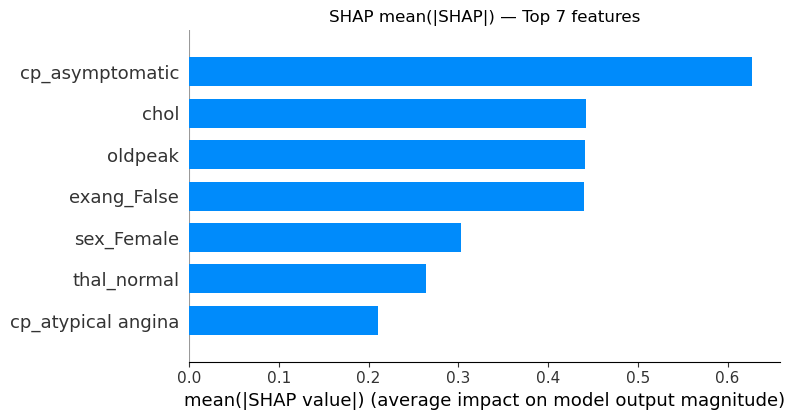

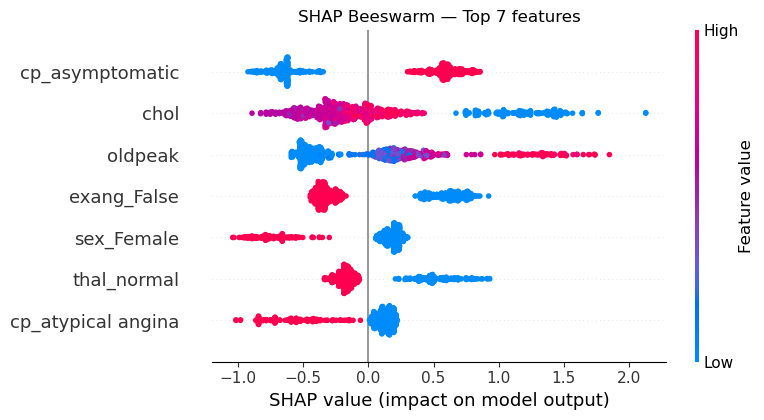

In [8]:
# Cell 8: global SHAP visualizations
plt.figure(figsize=(8,4))
shap.summary_plot(shap_vals, X_top7, feature_names=top7, plot_type='bar', show=False)
plt.title("SHAP mean(|SHAP|) — Top 7 features")
plt.tight_layout()
plt.savefig("../figures/shap_bar_top7.png", dpi=250)
plt.show()

plt.figure(figsize=(8,5))
shap.summary_plot(shap_vals, X_top7, feature_names=top7, show=False)
plt.title("SHAP Beeswarm — Top 7 features")
plt.tight_layout()
plt.savefig("../figures/shap_beeswarm_top7.png", dpi=250)
plt.show()


In [9]:
# Cell 9: local explanations and clinical summary
# compute probabilities using the saved (calibrated) model on raw X_df
probs = model.predict_proba(X_df)[:,1]   # calibrated wrapper returns real probabilities

idx_high = int(np.argmax(probs))
idx_low = int(np.argmin(probs))
idx_border = int(np.argsort(np.abs(probs - 0.5))[0])

sample_indices = [idx_high, idx_border, idx_low]
print("sample indices (high, border, low):", sample_indices)
print("sample probs:", probs[sample_indices])

# function to create a small clinical summary text and JSON
def synthesize_clinical_summary(shap_values_row, feature_names, prob, top_n=3):
    pairs = sorted(zip(feature_names, shap_values_row.tolist()), key=lambda x: -abs(x[1]))
    pos = [f"{n} (+{v:.3f})" for n,v in pairs if v>0][:top_n]
    neg = [f"{n} ({v:.3f})" for n,v in pairs if v<0][:top_n]
    txt = f"Predicted risk: {prob*100:.1f}%. Drivers increasing risk: {', '.join(pos) if pos else 'None'}. Drivers decreasing risk: {', '.join(neg) if neg else 'None'}."
    json_obj = {
        "probability": float(prob),
        "predicted_label": int(prob>=0.5),
        "top_positive": [{"feature": n, "shap": float(v)} for n,v in pairs if v>0][:top_n],
        "top_negative": [{"feature": n, "shap": float(v)} for n,v in pairs if v<0][:top_n],
        "all_drivers": [{"feature": n, "shap": float(v)} for n,v in pairs]
    }
    return txt, json_obj

for si in sample_indices:
    # force plot (matplotlib)
    plt.figure(figsize=(6,4))
    shap.force_plot(expected_value, shap_vals[si], features=X_top7[si], feature_names=top7, matplotlib=True, show=False)
    plt.title(f"SHAP force (sample {si}, prob={probs[si]:.3f})")
    plt.tight_layout()
    plt.savefig(f"../figures/shap_force_sample{si}.png", dpi=250)
    plt.show()

    # decision plot
    plt.figure(figsize=(6,4))
    shap.decision_plot(expected_value, shap_vals[si], feature_names=top7, show=False)
    plt.title(f"SHAP decision (sample {si})")
    plt.tight_layout()
    plt.savefig(f"../figures/shap_decision_sample{si}.png", dpi=250)
    plt.show()

# generate and save clinical explanation for the highest-risk sample (idx_high)
txt, json_obj = synthesize_clinical_summary(shap_vals[idx_high], top7, probs[idx_high], top_n=3)
with open(f"../artifacts/clinical_summary_sample{idx_high}.txt","w") as f:
    f.write(txt)
json.dump(json_obj, open(f"../artifacts/clinical_explanation_sample{idx_high}.json","w"), indent=2)
print("Clinical summary saved for sample", idx_high)
print(txt)


AttributeError: 'ColumnSelector' object has no attribute 'columns'

In [10]:
sample_idx = 10   # change as you want

shap.force_plot(
    expected_value, 
    shap_values[sample_idx, :], 
    feature_names=top7, 
    matplotlib=True
)
plt.savefig("../figures/shap_force_sample10.png", dpi=200)
plt.show()


NameError: name 'shap_values' is not defined

In [36]:
def clinical_explanation(values, features, names):
    positive = []
    negative = []
    for val, name in zip(values, names):
        if val > 0:
            positive.append((name, val))
        else:
            negative.append((name, val))
    positive = sorted(positive, key=lambda x: abs(x[1]), reverse=True)
    negative = sorted(negative, key=lambda x: abs(x[1]), reverse=True)
    return positive, negative

pos, neg = clinical_explanation(shap_values[sample_idx], X_top7[sample_idx], top7)

print("Factors increasing risk:")
for name,val in pos:
    print(f"  {name}: +{val:.4f}")

print("\nFactors decreasing risk:")
for name,val in neg:
    print(f"  {name}: {val:.4f}")


NameError: name 'shap_values' is not defined